<a href="https://colab.research.google.com/github/Rakib911Hossan/ml-penta/blob/dev/roberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import re
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaModel, RobertaTokenizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



Using Colab cache for faster access to the 'emotion-detection-from-text' dataset.
Files: ['tweet_emotions.csv']
Shape: (40000, 3)
Unique sentiments: ['anger', 'boredom', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise', 'worry']


/tmp/ipykernel_9534/4244506955.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sentiment', data=df, order=order_all, palette='viridis', ax=axes[0])


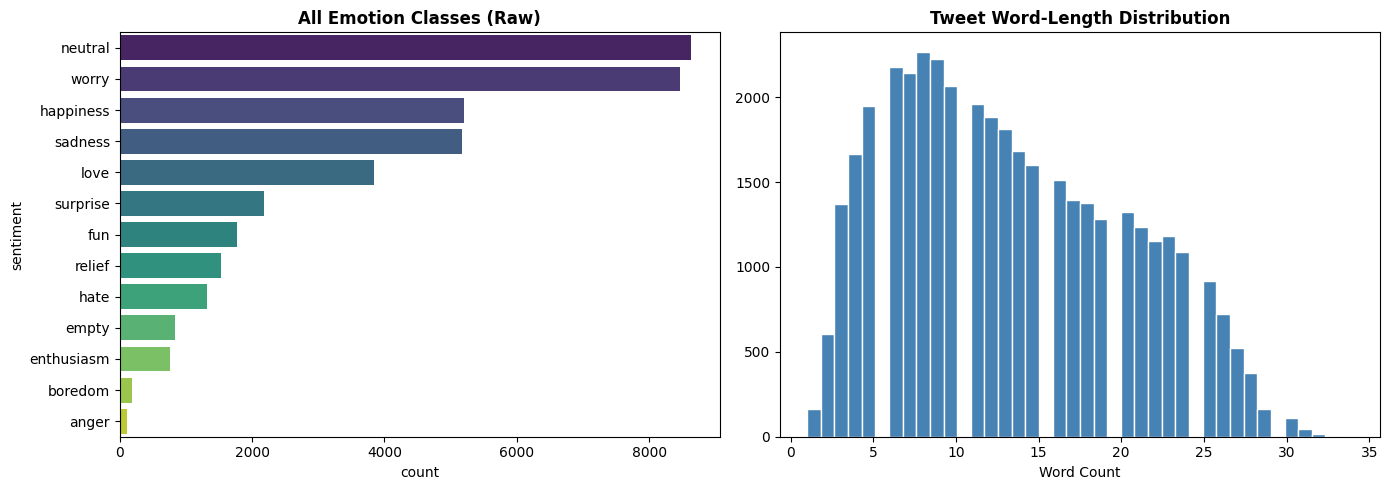

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


In [2]:
# ---- Config ----
class CFG:
    seed = 42
    num_labels = None

# ---- Data Loading ----
path = kagglehub.dataset_download("pashupatigupta/emotion-detection-from-text")
print("Files:", os.listdir(path))

df = pd.read_csv(f"{path}/tweet_emotions.csv")
print("Shape:", df.shape)
print("Unique sentiments:", sorted(df['sentiment'].unique()))

# ---- EDA Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_all = df['sentiment'].value_counts().index
sns.countplot(y='sentiment', data=df, order=order_all, palette='viridis', ax=axes[0])
axes[0].set_title('All Emotion Classes (Raw)', fontweight='bold')

df['text_length'] = df['content'].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Tweet Word-Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()
print(df['sentiment'].value_counts())



                                                                                                                                content                                                                                                                            clean_text   sentiment
0                                          @tiffanylue i know  i was listenin to bad habit earlier and i started freakin at his part =[                                                       i know i was listenin to bad habit earlier and i started freakin at his part =[       empty
1                                                                          Layin n bed with a headache  ughhhh...waitin on your call...                                                                           Layin n bed with a headache ughhhh...waitin on your call...     sadness
2                                                                                                   Funeral ceremony...gloomy friday...                   

/tmp/ipykernel_9534/3934069521.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_grouped', data=df,


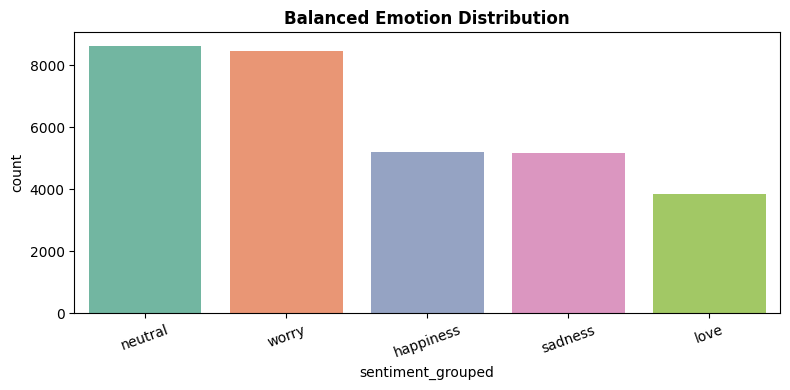

In [3]:
# ---- Preprocessing ----
def preprocess(text: str) -> str:
    text = str(text)
    text = re.sub(r'@\w+', '', text)           # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

df['clean_text'] = df['content'].apply(preprocess)
print(df[['content', 'clean_text', 'sentiment']].head(8).to_string())

# ---- Filter Top Emotions ----
top_emotions = ['neutral', 'worry', 'happiness', 'sadness', 'love']
df = df[df['sentiment'].isin(top_emotions)].copy()
df['sentiment_grouped'] = df['sentiment']
print("Before balancing:\n", df['sentiment_grouped'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(x='sentiment_grouped', data=df,
              order=df['sentiment_grouped'].value_counts().index,
              palette='Set2')
plt.title('Balanced Emotion Distribution', fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



In [4]:
# ---- Split ----
min_words = 2
X = df['clean_text']
Y = df['sentiment_grouped']

X_train_dev, X_test, Y_train_dev, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=CFG.seed, stratify=Y
)
X_train, X_dev, Y_train, Y_dev = train_test_split(
    X_train_dev, Y_train_dev, test_size=0.25, random_state=CFG.seed, stratify=Y_train_dev
)

# ---- Clean NaN and Short Samples ----
X_train = X_train.fillna("").astype(str)
X_dev   = X_dev.fillna("").astype(str)
X_test  = X_test.fillna("").astype(str)

mask_train = X_train.str.split().apply(len) >= min_words
mask_dev   = X_dev.str.split().apply(len)   >= min_words
mask_test  = X_test.str.split().apply(len)  >= min_words

X_train = X_train[mask_train].reset_index(drop=True)
Y_train = Y_train[mask_train].reset_index(drop=True)
X_dev   = X_dev[mask_dev].reset_index(drop=True)
Y_dev   = Y_dev[mask_dev].reset_index(drop=True)
X_test  = X_test[mask_test].reset_index(drop=True)
Y_test  = Y_test[mask_test].reset_index(drop=True)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test: {len(X_test)}")



Train: 18557 | Dev: 6193 | Test: 6181


In [5]:
# ---- Label Encoding ----
le = LabelEncoder()
le.fit(Y)
Y_train_enc = le.transform(Y_train)
Y_dev_enc   = le.transform(Y_dev)
Y_test_enc  = le.transform(Y_test)

id2label = {i: lbl for i, lbl in enumerate(le.classes_)}
label2id = {lbl: i for i, lbl in id2label.items()}
CFG.num_labels = len(le.classes_)
print("Label mapping:", id2label)

# ---- Tokenizer ----
tokenizer = RobertaTokenizer.from_pretrained('cardiffnlp/twitter-roberta-base-emotion')

token_lengths = X_train.apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)
print(token_lengths.describe())



Label mapping: {0: 'happiness', 1: 'love', 2: 'neutral', 3: 'sadness', 4: 'worry'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

count    18557.000000
mean        18.926497
std          9.386241
min          4.000000
25%         11.000000
50%         17.000000
75%         26.000000
max        114.000000
Name: clean_text, dtype: float64


In [6]:
# ---- Dataset ----
class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=128,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(X_train, Y_train_enc)
dev_dataset   = EmotionDataset(X_dev,   Y_dev_enc)
test_dataset  = EmotionDataset(X_test,  Y_test_enc)

print(f"Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}")



Train: 18557 | Dev: 6193 | Test: 6181


In [7]:
# ---- DataLoaders ----
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dev_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

# ---- Model ----
roberta_model = RobertaModel.from_pretrained('cardiffnlp/twitter-roberta-base-emotion').to(device)

class EmotionClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super(EmotionClassifier, self).__init__()
        self.bert_model = bert_model
        self.dropout    = nn.Dropout(0.2)
        self.fc1        = nn.Linear(bert_model.config.hidden_size, 512)
        self.gelu       = nn.GELU()
        self.layer_norm = nn.LayerNorm(512)
        self.fc2        = nn.Linear(512, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x          = self.fc1(cls_output)
        x          = self.gelu(x)
        x          = self.layer_norm(x)
        x          = self.dropout(x)
        logits     = self.fc2(x)
        return logits



config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-emotion
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.bias        | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ---- Init ----
num_epochs = 4
is_train   = True
classifier = EmotionClassifier(roberta_model, CFG.num_labels).to(device)

optimizer = torch.optim.Adam([
    {'params': classifier.bert_model.parameters(), 'lr': 1e-5},
    {'params': list(classifier.fc1.parameters()) + list(classifier.fc2.parameters()) +
               list(classifier.layer_norm.parameters()), 'lr': 3e-5}
])

from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ---- Training ----
if is_train:
    for epoch in range(num_epochs):
        classifier.train()
        train_loss    = 0.0
        train_correct = 0
        total         = 0

        for batch_idx, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = classifier(input_ids, attention_mask)
            _, predicted = torch.max(outputs, dim=1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            total         += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_loss    += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx}/{len(train_loader)} | Loss: {train_loss/(batch_idx+1):.4f} | Accuracy: {train_correct/total:.4f}")

        train_accuracy = train_correct / total
        train_loss    /= len(train_loader)

    torch.save(classifier.state_dict(), '/tmp/classifier_params.pth')
# ---- Validation ----
classifier.load_state_dict(torch.load('/tmp/classifier_params.pth', map_location=device))
classifier.eval()
valid_loss    = 0.0
valid_correct = 0
total         = 0

with torch.no_grad():
    for batch in valid_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = classifier(input_ids, attention_mask)
        _, predicted = torch.max(outputs, dim=1)
        loss = criterion(outputs, labels)

        total         += labels.size(0)
        valid_correct += (predicted == labels).sum().item()
        valid_loss    += loss.item()

valid_accuracy = valid_correct / total
valid_loss    /= len(valid_loader)
print(f'Epoch {num_epochs}/{num_epochs}')
print(f'Training Loss: {train_loss:.4f} | Training Accuracy: {train_accuracy:.4f}')
print(f'Validation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_accuracy:.4f}')
print('------------------------------------------')



Epoch 1/4 | Batch 0/580 | Loss: 1.7900 | Accuracy: 0.1562
Epoch 1/4 | Batch 100/580 | Loss: 1.2741 | Accuracy: 0.5334
Epoch 1/4 | Batch 200/580 | Loss: 0.9860 | Accuracy: 0.7016
Epoch 1/4 | Batch 300/580 | Loss: 0.8689 | Accuracy: 0.7665
Epoch 1/4 | Batch 400/580 | Loss: 0.8133 | Accuracy: 0.7973
Epoch 1/4 | Batch 500/580 | Loss: 0.7751 | Accuracy: 0.8182
Epoch 2/4 | Batch 0/580 | Loss: 0.6130 | Accuracy: 0.8750
Epoch 2/4 | Batch 100/580 | Loss: 0.5871 | Accuracy: 0.9152
Epoch 2/4 | Batch 200/580 | Loss: 0.5890 | Accuracy: 0.9150
Epoch 2/4 | Batch 300/580 | Loss: 0.5830 | Accuracy: 0.9189
Epoch 2/4 | Batch 400/580 | Loss: 0.5803 | Accuracy: 0.9198
Epoch 2/4 | Batch 500/580 | Loss: 0.5758 | Accuracy: 0.9211
Epoch 3/4 | Batch 0/580 | Loss: 0.4539 | Accuracy: 0.9688
Epoch 3/4 | Batch 100/580 | Loss: 0.5262 | Accuracy: 0.9468
Epoch 3/4 | Batch 200/580 | Loss: 0.5340 | Accuracy: 0.9411


In [9]:
torch.save(classifier.state_dict(), '/tmp/classifier_params.pth')
# ---- Validation ----
classifier.load_state_dict(torch.load('/tmp/classifier_params.pth', map_location=device))
classifier.eval()
valid_loss    = 0.0
valid_correct = 0
total         = 0

with torch.no_grad():
    for batch in valid_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = classifier(input_ids, attention_mask)
        _, predicted = torch.max(outputs, dim=1)
        loss = criterion(outputs, labels)

        total         += labels.size(0)
        valid_correct += (predicted == labels).sum().item()
        valid_loss    += loss.item()

valid_accuracy = valid_correct / total
valid_loss    /= len(valid_loader)
print(f'Epoch {num_epochs}/{num_epochs}')
print(f'Training Loss: {train_loss:.4f} | Training Accuracy: {train_accuracy:.4f}')
print(f'Validation Loss: {valid_loss:.4f} | Validation Accuracy: {valid_accuracy:.4f}')
print('------------------------------------------')


Epoch 10/10
Training Loss: 0.6258 | Training Accuracy: 0.8927
Validation Loss: 1.7891 | Validation Accuracy: 0.4604
------------------------------------------


In [10]:
# ---- Testing ----
classifier.eval()
test_loss    = 0.0
test_correct = 0
total        = 0
predictions  = []
true_labels  = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = classifier(input_ids, attention_mask)
        _, predicted = torch.max(outputs, dim=1)
        loss = criterion(outputs, labels)

        total        += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_loss    += loss.item()
        predictions.extend(predicted.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

test_accuracy = test_correct / total
test_loss    /= len(test_loader)
print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}')

# ---- Results ----
predicted_labels = le.inverse_transform(predictions)
true_labels      = le.inverse_transform(true_labels)

print('Classification Report:')
print(classification_report(true_labels, predicted_labels))
print('Confusion Matrix:')
print(confusion_matrix(true_labels, predicted_labels))

Test Loss: 1.7759 | Test Accuracy: 0.4629
Classification Report:
              precision    recall  f1-score   support

   happiness       0.46      0.43      0.45      1037
        love       0.44      0.49      0.46       762
     neutral       0.52      0.46      0.49      1674
     sadness       0.40      0.33      0.36      1028
       worry       0.46      0.56      0.50      1680

    accuracy                           0.46      6181
   macro avg       0.46      0.45      0.45      6181
weighted avg       0.46      0.46      0.46      6181

Confusion Matrix:
[[444 228 188  48 129]
 [181 373  79  43  86]
 [194 133 762 145 440]
 [ 36  43 148 339 462]
 [103  73 283 278 943]]
